## Highest Test Accuracy: 66.67%

## Load Data and Drop Channel and Snipping

In [1]:
import numpy as np

data = np.load("Datasets/Main.npz")
X = data["X_raw"]
y = data["y"]  

BAD_CHANNELS = [0,1,2,6,7]
X = np.delete(X, BAD_CHANNELS, axis=1)
print(X.shape)


(480, 3, 1750)


## Bandpassing

In [2]:
import numpy as np
from brainflow.data_filter import (
    DataFilter,
    FilterTypes,
    DetrendOperations
)

SAMPLING_RATE = 250  
LOW_CUT = 8
HIGH_CUT = 13
FILTER_ORDER = 4

X_filtered = np.copy(X)

for trial in range(X.shape[0]):

    for ch in range(X.shape[1]):

        signal = X_filtered[trial, ch]
        signal = np.ascontiguousarray(
            signal,
            dtype=np.float64
        )

        # Remove DC offset
        DataFilter.detrend(
            signal,
            DetrendOperations.CONSTANT.value
        )

        # 3–45 Hz Bandpass
        DataFilter.perform_bandpass(
            signal,
            SAMPLING_RATE,
            LOW_CUT,
            HIGH_CUT,
            FILTER_ORDER,
            FilterTypes.BUTTERWORTH_ZERO_PHASE.value,
            0
        )

        DataFilter.remove_environmental_noise(
            signal,
            SAMPLING_RATE,
            1
        )

        X_filtered[trial, ch] = signal

print("Original Shape :", X.shape)
print("Filtered Shape :", X_filtered.shape)

X = X_filtered

c:\Stored Data\BrainDance\venv\Lib\site-packages\brainflow\board_shim.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Original Shape : (480, 3, 1750)
Filtered Shape : (480, 3, 1750)


## Data Snipping

In [3]:
X_snipped = X[:, :, 500:-50]
X = X_snipped
print("Original Shape :", X.shape)
print("Snipped Shape  :", X_snipped.shape)

Original Shape : (480, 3, 1200)
Snipped Shape  : (480, 3, 1200)


## Noisy Trial Rejection

In [4]:
import numpy as np

def reject_noisy_trials(
    X,
    y,
    max_abs_thresh=250,
    ptp_thresh=500,
    std_z_thresh=3.0,
    flat_std_thresh=1e-6,
    verbose=True
):
    """
    X shape: (trials, channels, samples)
    y shape: (trials,)
    """

    # =========================
    # TRIAL / CHANNEL STATS
    # =========================

    max_abs = np.max(np.abs(X), axis=2)    # (trials, channels)
    ptp = np.ptp(X, axis=2)                # (trials, channels)
    std = np.std(X, axis=2)                # (trials, channels)

    trial_max_abs = np.max(max_abs, axis=1)
    trial_ptp = np.max(ptp, axis=1)
    trial_mean_std = np.mean(std, axis=1)

    median_std = np.median(trial_mean_std)
    mad_std = np.median(np.abs(trial_mean_std - median_std)) + 1e-12
    robust_z_std = 0.6745 * (trial_mean_std - median_std) / mad_std

    # =========================
    # REJECTION REASONS
    # =========================

    reason_max_abs = trial_max_abs > max_abs_thresh
    reason_ptp = trial_ptp > ptp_thresh
    reason_std_z = np.abs(robust_z_std) > std_z_thresh
    reason_flat = np.any(std < flat_std_thresh, axis=1)

    reject_mask = (
        reason_max_abs |
        reason_ptp |
        reason_std_z |
        reason_flat
    )

    keep_mask = ~reject_mask

    X_clean = X[keep_mask]
    y_clean = y[keep_mask]

    # =========================
    # SUMMARY
    # =========================

    if verbose:
        print("=" * 60)
        print("TRIAL REJECTION SUMMARY")
        print("=" * 60)

        print("Original trials :", len(X))
        print("Rejected trials :", int(np.sum(reject_mask)))
        print("Remaining trials:", len(X_clean))

        print("\nRejection reason counts:")
        print("Max abs exceeded :", int(np.sum(reason_max_abs)))
        print("PTP exceeded     :", int(np.sum(reason_ptp)))
        print("STD z-score bad  :", int(np.sum(reason_std_z)))
        print("Flat signal      :", int(np.sum(reason_flat)))

        print("\nRejected trial details:")
        rejected_indices = np.where(reject_mask)[0]

        if len(rejected_indices) == 0:
            print("None")
        else:
            for idx in rejected_indices:
                reasons = []

                if reason_max_abs[idx]:
                    reasons.append(
                        f"max_abs={trial_max_abs[idx]:.2f} > {max_abs_thresh}"
                    )

                if reason_ptp[idx]:
                    reasons.append(
                        f"ptp={trial_ptp[idx]:.2f} > {ptp_thresh}"
                    )

                if reason_std_z[idx]:
                    reasons.append(
                        f"std_z={robust_z_std[idx]:+.2f} > ±{std_z_thresh}"
                    )

                if reason_flat[idx]:
                    flat_channels = np.where(std[idx] < flat_std_thresh)[0]
                    reasons.append(
                        f"flat channels={flat_channels.tolist()}"
                    )

                print(f"Trial {idx}: " + " | ".join(reasons))

        print("\nClass balance before:")
        print(dict(zip(*np.unique(y, return_counts=True))))

        print("\nClass balance after:")
        print(dict(zip(*np.unique(y_clean, return_counts=True))))

    return {
        "X_clean": X_clean,
        "y_clean": y_clean,
        "keep_mask": keep_mask,
        "reject_mask": reject_mask,

        "reasons": {
            "max_abs": reason_max_abs,
            "ptp": reason_ptp,
            "std_z": reason_std_z,
            "flat": reason_flat,
        },

        "stats": {
            "trial_max_abs": trial_max_abs,
            "trial_ptp": trial_ptp,
            "trial_mean_std": trial_mean_std,
            "robust_z_std": robust_z_std,
        }
    }


result = reject_noisy_trials(
    X,
    y,
    max_abs_thresh=250,
    ptp_thresh=350,
    std_z_thresh=3.0
)

X = result["X_clean"]
y = result["y_clean"]

keep_mask = result["keep_mask"]
reject_mask = result["reject_mask"]
reasons = result["reasons"]
stats = result["stats"]

TRIAL REJECTION SUMMARY
Original trials : 480
Rejected trials : 43
Remaining trials: 437

Rejection reason counts:
Max abs exceeded : 11
PTP exceeded     : 13
STD z-score bad  : 43
Flat signal      : 0

Rejected trial details:
Trial 18: std_z=+3.40 > ±3.0
Trial 25: std_z=+5.70 > ±3.0
Trial 30: max_abs=415.76 > 250 | ptp=711.49 > 350 | std_z=+16.07 > ±3.0
Trial 37: std_z=+3.15 > ±3.0
Trial 59: max_abs=359.50 > 250 | ptp=611.41 > 350 | std_z=+6.37 > ±3.0
Trial 60: std_z=+8.16 > ±3.0
Trial 85: std_z=+3.70 > ±3.0
Trial 89: std_z=+4.43 > ±3.0
Trial 118: std_z=+3.89 > ±3.0
Trial 132: std_z=+4.15 > ±3.0
Trial 136: ptp=364.83 > 350 | std_z=+11.95 > ±3.0
Trial 137: std_z=+3.04 > ±3.0
Trial 141: ptp=380.16 > 350 | std_z=+12.07 > ±3.0
Trial 142: std_z=+5.24 > ±3.0
Trial 164: std_z=+12.09 > ±3.0
Trial 172: std_z=+3.73 > ±3.0
Trial 186: max_abs=8849.74 > 250 | ptp=17663.87 > 350 | std_z=+796.24 > ±3.0
Trial 199: max_abs=1110.54 > 250 | ptp=2190.85 > 350 | std_z=+436.09 > ±3.0
Trial 239: std_z=+4.89

## Train Test Val Split

In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,   # 70% train
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,   # 15% val, 15% test
    random_state=42,
    stratify=y_temp
)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print()

print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

print("\nTrain class balance:")
print(np.unique(y_train, return_counts=True))

print("\nValidation class balance:")
print(np.unique(y_val, return_counts=True))

print("\nTest class balance:")
print(np.unique(y_test, return_counts=True))

X_train shape: (305, 3, 1200)
X_val shape  : (66, 3, 1200)
X_test shape : (66, 3, 1200)

y_train shape: (305,)
y_val shape  : (66,)
y_test shape : (66,)

Train class balance:
(array([1, 2]), array([156, 149]))

Validation class balance:
(array([1, 2]), array([33, 33]))

Test class balance:
(array([1, 2]), array([34, 32]))


## Feature Extraction

In [6]:
import numpy as np
from scipy.signal import welch
from scipy.linalg import eigh
from itertools import combinations
from sklearn.preprocessing import StandardScaler


# ============================================================
# CONFIG
# ============================================================

FS = 250

# Set to -1 if the channel was already dropped earlier.
# Any other number is the channel index inside X.
C3_IDX = 0
CZ_IDX = 1
C4_IDX = 2

CSP_COMPONENTS = 6

USE_CSP = True
USE_COVARIANCE_GEOMETRY = True

BANDS = {
    "theta": (4, 8),
    "mu": (8, 13),
    "beta": (13, 30),
    "mi": (8, 30),
}

RATIO_PAIRS = [
    ("mu", "beta"),
    ("mu", "theta"),
    ("beta", "theta"),
    ("mi", "theta"),
    ("mu", "mi"),
    ("beta", "mi"),
]


# ============================================================
# SAFE HELPERS
# ============================================================

def safe_array(x):
    return np.nan_to_num(
        np.asarray(x, dtype=np.float64),
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )


def safe_value(x):
    try:
        if np.isnan(x) or np.isinf(x):
            return 0.0
        return float(x)
    except Exception:
        return 0.0


def safe_log(x):
    return np.log(float(x) + 1e-12)


def get_valid_motor_indices(X, c3_idx, cz_idx, c4_idx):
    """
    Reads X shape and returns only valid motor-channel indices.

    X shape must be:
        (trials, channels, samples)

    - index == -1 means channel was dropped earlier
    - any other value must be a valid channel index inside X
    """

    if X.ndim != 3:
        raise ValueError(f"X must have shape (trials, channels, samples), got {X.shape}")

    n_trials, n_channels, n_samples = X.shape

    print("Input data shape:")
    print("Trials  :", n_trials)
    print("Channels:", n_channels)
    print("Samples :", n_samples)

    raw_indices = {
        "C3": c3_idx,
        "Cz": cz_idx,
        "C4": c4_idx,
    }

    valid_indices = []
    valid_labels = []

    for label, idx in raw_indices.items():
        if idx == -1:
            print(f"{label}: dropped earlier, skipping.")
            continue

        if idx < 0 or idx >= n_channels:
            raise ValueError(
                f"{label}_IDX={idx} is invalid for X with {n_channels} channels."
            )

        valid_indices.append(idx)
        valid_labels.append(label)

    if len(valid_indices) == 0:
        raise ValueError("No valid motor channels found. C3_IDX, CZ_IDX, and C4_IDX are all -1.")

    print("Using motor channels:")
    for label, idx in zip(valid_labels, valid_indices):
        print(f"{label}: X[:, {idx}, :]")

    return valid_indices, valid_labels


# ============================================================
# PSD / BANDPOWER
# ============================================================

def welch_psd(signal, fs):
    signal = safe_array(signal)

    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=min(256, len(signal)),
        noverlap=min(128, len(signal) // 2)
    )

    psd = np.nan_to_num(
        psd,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return freqs, psd + 1e-12


def bandpower_welch(signal, fs, low, high):
    freqs, psd = welch_psd(signal, fs)

    mask = (freqs >= low) & (freqs <= high)

    if not np.any(mask):
        return 0.0

    return safe_value(np.mean(psd[mask]))


# ============================================================
# CSP
# ============================================================

def covariance_matrix(trial):
    """
    trial shape:
        (selected_channels, samples)
    """

    trial = safe_array(trial)

    cov = trial @ trial.T
    cov /= np.trace(cov) + 1e-12

    return cov


def fit_csp(X_train_selected, y_train, n_components=4):
    """
    X_train_selected shape:
        (trials, selected_channels, samples)
    """

    classes = np.unique(y_train)

    if len(classes) != 2:
        raise ValueError("CSP expects binary labels.")

    n_channels = X_train_selected.shape[1]

    if n_channels < 2:
        print("CSP disabled automatically because fewer than 2 channels are available.")
        return None

    n_components = min(n_components, n_channels)

    if n_components % 2 != 0:
        n_components -= 1

    if n_components < 2:
        print("CSP disabled automatically because valid CSP components < 2.")
        return None

    cov_0 = np.mean(
        [covariance_matrix(x) for x in X_train_selected[y_train == classes[0]]],
        axis=0
    )

    cov_1 = np.mean(
        [covariance_matrix(x) for x in X_train_selected[y_train == classes[1]]],
        axis=0
    )

    eigvals, eigvecs = eigh(cov_0, cov_0 + cov_1)

    ix = np.argsort(eigvals)
    eigvecs = eigvecs[:, ix]

    half = n_components // 2

    filters = np.concatenate(
        [
            eigvecs[:, :half],
            eigvecs[:, -half:]
        ],
        axis=1
    )

    return filters.T


def csp_logvar_features(trial_selected, csp_filters):
    trial_selected = safe_array(trial_selected)

    projected = csp_filters @ trial_selected

    var = np.var(projected, axis=1)
    norm_var = var / (np.sum(var) + 1e-12)

    return np.log(norm_var + 1e-12)


# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_trial_features(trial_selected, selected_labels, fs):
    """
    Extracts features only from the valid selected motor channels.

    trial_selected shape:
        (selected_channels, samples)
    """

    trial_selected = safe_array(trial_selected)

    row = []
    names = []

    power_cache = {}

    # --------------------------------------------------------
    # 1. Per-channel features
    # --------------------------------------------------------

    for ch_i, label in enumerate(selected_labels):
        sig = trial_selected[ch_i]

        power_cache[label] = {}

        for band_name, (low, high) in BANDS.items():
            p = bandpower_welch(sig, fs, low, high)

            power_cache[label][band_name] = p

            row.append(p)
            names.append(f"{label}_{band_name}_power")

            row.append(safe_log(p))
            names.append(f"{label}_log_{band_name}_power")

        var = np.var(sig)
        std = np.std(sig)
        ptp = np.ptp(sig)
        rms = np.sqrt(np.mean(sig ** 2))
        mean_abs = np.mean(np.abs(sig))

        row.extend([
            safe_log(var),
            std,
            ptp,
            rms,
            mean_abs,
        ])

        names.extend([
            f"{label}_logvar",
            f"{label}_std",
            f"{label}_ptp",
            f"{label}_rms",
            f"{label}_mean_abs",
        ])

    # --------------------------------------------------------
    # 2. Band ratios per channel
    # --------------------------------------------------------

    for label in selected_labels:
        for a, b in RATIO_PAIRS:
            pa = power_cache[label][a]
            pb = power_cache[label][b]

            row.append(pa / (pb + 1e-12))
            names.append(f"{label}_{a}_over_{b}")

            row.append(safe_log(pa) - safe_log(pb))
            names.append(f"{label}_log_{a}_minus_log_{b}")

    # --------------------------------------------------------
    # 3. Pairwise features
    #    Only created if at least 2 motor channels exist.
    # --------------------------------------------------------

    for i, j in combinations(range(len(selected_labels)), 2):
        label_a = selected_labels[i]
        label_b = selected_labels[j]

        sig_a = trial_selected[i]
        sig_b = trial_selected[j]

        bipolar = sig_a - sig_b
        pair_label = f"{label_a}_minus_{label_b}"

        for band_name, (low, high) in BANDS.items():
            pa = power_cache[label_a][band_name]
            pb = power_cache[label_b][band_name]

            diff = pa - pb
            logdiff = safe_log(pa) - safe_log(pb)
            lateralization = (pa - pb) / (pa + pb + 1e-12)

            row.extend([
                diff,
                logdiff,
                lateralization,
            ])

            names.extend([
                f"{label_a}_{label_b}_{band_name}_power_diff",
                f"{label_a}_{label_b}_{band_name}_log_power_diff",
                f"{label_a}_{label_b}_{band_name}_lateralization",
            ])

            bp = bandpower_welch(bipolar, fs, low, high)

            row.append(bp)
            names.append(f"{pair_label}_{band_name}_power")

            row.append(safe_log(bp))
            names.append(f"{pair_label}_log_{band_name}_power")

        row.append(safe_log(np.var(bipolar)))
        names.append(f"{pair_label}_logvar")

        row.append(np.std(bipolar))
        names.append(f"{pair_label}_std")

        row.append(np.ptp(bipolar))
        names.append(f"{pair_label}_ptp")

    row = [safe_value(v) for v in row]

    return row, names


def covariance_geometry_features(trial_selected):
    """
    Uses only selected motor channels.
    """

    trial_selected = safe_array(trial_selected)

    if trial_selected.shape[0] < 2:
        return [], []

    cov = np.cov(trial_selected)

    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.sort(np.abs(eigvals))[::-1]
    eigvals_norm = eigvals / (np.sum(eigvals) + 1e-12)

    vals = [
        eigvals_norm[0],
        eigvals_norm[1] if len(eigvals_norm) > 1 else 0.0,
        eigvals_norm[0] / (eigvals_norm[-1] + 1e-12),
        -np.sum(eigvals_norm * np.log(eigvals_norm + 1e-12)),
    ]

    names = [
        "cov_eigen_1",
        "cov_eigen_2",
        "cov_condition_ratio",
        "cov_eigen_entropy",
    ]

    vals = [safe_value(v) for v in vals]

    return vals, names


# ============================================================
# EXTRACTOR CLASS
# ============================================================

class MotorChannelFeatureExtractor:
    def __init__(
        self,
        c3_idx,
        cz_idx,
        c4_idx,
        fs=250,
        use_csp=True,
        csp_components=4,
        use_covariance_geometry=True,
    ):
        self.c3_idx = c3_idx
        self.cz_idx = cz_idx
        self.c4_idx = c4_idx

        self.fs = fs
        self.use_csp = use_csp
        self.csp_components = csp_components
        self.use_covariance_geometry = use_covariance_geometry

        self.selected_indices = None
        self.selected_labels = None

        self.csp_filters = None
        self.scaler = StandardScaler()
        self.feature_names = None

    def _select_motor_channels(self, X):
        return X[:, self.selected_indices, :]

    def fit_transform(self, X_train, y_train):
        self.selected_indices, self.selected_labels = get_valid_motor_indices(
            X_train,
            self.c3_idx,
            self.cz_idx,
            self.c4_idx
        )

        X_train_selected = self._select_motor_channels(X_train)

        if self.use_csp:
            self.csp_filters = fit_csp(
                X_train_selected,
                y_train,
                n_components=self.csp_components
            )

        raw_features, names = self._extract_raw(X_train_selected)

        raw_features = np.nan_to_num(
            raw_features,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        scaled_features = self.scaler.fit_transform(raw_features)

        scaled_features = np.nan_to_num(
            scaled_features,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        self.feature_names = names

        return scaled_features

    def transform(self, X):
        if self.selected_indices is None:
            raise RuntimeError("You must call fit_transform() before transform().")

        if X.ndim != 3:
            raise ValueError(f"X must have shape (trials, channels, samples), got {X.shape}")

        print("Transform data shape:")
        print("Trials  :", X.shape[0])
        print("Channels:", X.shape[1])
        print("Samples :", X.shape[2])

        X_selected = self._select_motor_channels(X)

        raw_features, _ = self._extract_raw(X_selected)

        raw_features = np.nan_to_num(
            raw_features,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        scaled_features = self.scaler.transform(raw_features)

        scaled_features = np.nan_to_num(
            scaled_features,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        return scaled_features

    def _extract_raw(self, X_selected):
        all_features = []
        final_names = None

        for trial_i in range(X_selected.shape[0]):
            trial = X_selected[trial_i]

            trial_features = []
            names = []

            f, n = extract_trial_features(
                trial_selected=trial,
                selected_labels=self.selected_labels,
                fs=self.fs
            )

            trial_features.extend(f)
            names.extend(n)

            if self.csp_filters is not None:
                csp_feats = csp_logvar_features(trial, self.csp_filters)

                for i, v in enumerate(csp_feats):
                    trial_features.append(safe_value(v))
                    names.append(f"csp_{i}_log_normalized_variance")

            if self.use_covariance_geometry:
                cov_feats, cov_names = covariance_geometry_features(trial)

                trial_features.extend(cov_feats)
                names.extend(cov_names)

            trial_features = [safe_value(v) for v in trial_features]
            all_features.append(trial_features)

            if final_names is None:
                final_names = names

        features = np.array(all_features, dtype=np.float32)

        features = np.nan_to_num(
            features,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        return features, final_names
    
extractor = MotorChannelFeatureExtractor(
    c3_idx=C3_IDX,
    cz_idx=CZ_IDX,
    c4_idx=C4_IDX,
    fs=FS,
    use_csp=USE_CSP,
    csp_components=CSP_COMPONENTS,
    use_covariance_geometry=USE_COVARIANCE_GEOMETRY
)

X_train_features = extractor.fit_transform(X_train, y_train)
X_val_features = extractor.transform(X_val)
X_test_features = extractor.transform(X_test)

feature_names = extractor.feature_names

print("\n================ FEATURE SUMMARY ================")
print("X_train_features:", X_train_features.shape)
print("X_val_features  :", X_val_features.shape)
print("X_test_features :", X_test_features.shape)
print("Number of features:", len(feature_names))

print("\nFirst 50 feature names:")
for i, name in enumerate(feature_names[:50]):
    print(i, name)

print("\nLast 30 feature names:")
for i, name in list(enumerate(feature_names))[-30:]:
    print(i, name)

Input data shape:
Trials  : 305
Channels: 3
Samples : 1200
Using motor channels:
C3: X[:, 0, :]
Cz: X[:, 1, :]
C4: X[:, 2, :]
Transform data shape:
Trials  : 66
Channels: 3
Samples : 1200
Transform data shape:
Trials  : 66
Channels: 3
Samples : 1200

================ FEATURE SUMMARY ================
X_train_features: (305, 150)
X_val_features  : (66, 150)
X_test_features : (66, 150)
Number of features: 150

First 50 feature names:
0 C3_theta_power
1 C3_log_theta_power
2 C3_mu_power
3 C3_log_mu_power
4 C3_beta_power
5 C3_log_beta_power
6 C3_mi_power
7 C3_log_mi_power
8 C3_logvar
9 C3_std
10 C3_ptp
11 C3_rms
12 C3_mean_abs
13 Cz_theta_power
14 Cz_log_theta_power
15 Cz_mu_power
16 Cz_log_mu_power
17 Cz_beta_power
18 Cz_log_beta_power
19 Cz_mi_power
20 Cz_log_mi_power
21 Cz_logvar
22 Cz_std
23 Cz_ptp
24 Cz_rms
25 Cz_mean_abs
26 C4_theta_power
27 C4_log_theta_power
28 C4_mu_power
29 C4_log_mu_power
30 C4_beta_power
31 C4_log_beta_power
32 C4_mi_power
33 C4_log_mi_power
34 C4_logvar
35 C4_st

## Obtain N Best Features

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from sklearn.feature_selection import mutual_info_classif

# Use unscaled features if available
# If only scaled features exist, this still works
Xf = X_train_features
yf = y_train

classes = np.unique(yf)
assert len(classes) == 2, "This snippet assumes binary classification."

c1, c2 = classes[0], classes[1]

X1 = Xf[yf == c1]
X2 = Xf[yf == c2]

feature_scores = []

for i in range(Xf.shape[1]):
    f1 = X1[:, i]
    f2 = X2[:, i]

    mean1 = np.mean(f1)
    mean2 = np.mean(f2)

    std1 = np.std(f1, ddof=1)
    std2 = np.std(f2, ddof=1)

    pooled_std = np.sqrt((std1**2 + std2**2) / 2) + 1e-12

    cohens_d = (mean1 - mean2) / pooled_std

    t_stat, p_val = ttest_ind(f1, f2, equal_var=False)

    feature_scores.append({
        "feature_index": i,
        "class_1_mean": mean1,
        "class_2_mean": mean2,
        "mean_diff": mean1 - mean2,
        "abs_mean_diff": abs(mean1 - mean2),
        "cohens_d": cohens_d,
        "abs_cohens_d": abs(cohens_d),
        "t_stat": t_stat,
        "abs_t_stat": abs(t_stat),
        "p_value": p_val
    })

df_scores = pd.DataFrame(feature_scores)

# Mutual information
mi = mutual_info_classif(Xf, yf, random_state=42)
df_scores["mutual_info"] = mi

# Sort by strongest separability
df_scores = df_scores.sort_values(
    by=["abs_cohens_d", "mutual_info", "abs_t_stat"],
    ascending=False
)

print(df_scores.head(20))

     feature_index  class_1_mean  class_2_mean  mean_diff  abs_mean_diff  \
66              66      0.151192     -0.158295   0.309488       0.309488   
65              65      0.149013     -0.156013   0.305026       0.305026   
70              70      0.148597     -0.155578   0.304176       0.304176   
69              69      0.147210     -0.154126   0.301336       0.301336   
41              41      0.137665     -0.144133   0.281798       0.281798   
45              45      0.136809     -0.143236   0.280045       0.280045   
105            105     -0.134106      0.140406  -0.274512       0.274512   
115            115     -0.133272      0.139533  -0.272805       0.272805   
104            104     -0.133007      0.139256  -0.272263       0.272263   
114            114     -0.132236      0.138448  -0.270685       0.270685   
42              42      0.132502     -0.138727   0.271229       0.271229   
46              46      0.130883     -0.137031   0.267914       0.267914   
113         

In [8]:
import numpy as np
import pandas as pd

def select_top_n_cohens_features(
    X_train_features,
    y_train,
    X_val_features,
    X_test_features,
    n=10
):
    classes = np.unique(y_train)
    assert len(classes) == 2, "Cohen's d selection assumes binary classification."

    c1, c2 = classes[0], classes[1]

    X1 = X_train_features[y_train == c1]
    X2 = X_train_features[y_train == c2]

    scores = []

    for i in range(X_train_features.shape[1]):
        f1 = X1[:, i]
        f2 = X2[:, i]

        mean1 = np.mean(f1)
        mean2 = np.mean(f2)

        std1 = np.std(f1, ddof=1)
        std2 = np.std(f2, ddof=1)

        pooled_std = np.sqrt((std1**2 + std2**2) / 2) + 1e-12
        cohens_d = (mean1 - mean2) / pooled_std

        scores.append({
            "feature_index": i,
            "cohens_d": cohens_d,
            "abs_cohens_d": abs(cohens_d),
            "class_1_mean": mean1,
            "class_2_mean": mean2
        })

    df_scores = pd.DataFrame(scores)

    df_scores = df_scores.sort_values(
        by="abs_cohens_d",
        ascending=False
    )

    selected_features = df_scores["feature_index"].head(n).to_numpy()

    X_train_selected = X_train_features[:, selected_features]
    X_val_selected = X_val_features[:, selected_features]
    X_test_selected = X_test_features[:, selected_features]

    return (
        X_train_selected,
        X_val_selected,
        X_test_selected,
        selected_features,
        df_scores
    )

n = 16

X_train_selected, X_val_selected, X_test_selected, selected_features, df_scores = (
    select_top_n_cohens_features(
        X_train_features,
        y_train,
        X_val_features,
        X_test_features,
        n=n
    )
)

print("X_train_selected:", X_train_selected.shape)
print("X_val_selected  :", X_val_selected.shape)
print("X_test_selected :", X_test_selected.shape)

print("\nTop selected features:")
print(df_scores.head(n))

X_train_selected: (305, 16)
X_val_selected  : (66, 16)
X_test_selected : (66, 16)

Top selected features:
     feature_index  cohens_d  abs_cohens_d  class_1_mean  class_2_mean
66              66  0.312363      0.312363      0.151192     -0.158295
65              65  0.308433      0.308433      0.149013     -0.156013
70              70  0.306887      0.306887      0.148597     -0.155578
69              69  0.304615      0.304615      0.147210     -0.154126
41              41  0.284403      0.284403      0.137665     -0.144133
45              45  0.282600      0.282600      0.136809     -0.143236
105            105 -0.277694      0.277694     -0.134106      0.140406
115            115 -0.275941      0.275941     -0.133272      0.139533
104            104 -0.275920      0.275920     -0.133007      0.139256
114            114 -0.274294      0.274294     -0.132236      0.138448
42              42  0.273153      0.273153      0.132502     -0.138727
46              46  0.269769      0.269769

## Fusion Architecture

In [9]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

device = torch.device("cpu")
print("Device:", device)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_val_scaled = scaler.transform(X_val_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Original labels:", np.unique(y_train))

if np.min(y_train) == 1:
    y_train_fixed = y_train - 1
    y_val_fixed = y_val - 1
    y_test_fixed = y_test - 1
else:
    y_train_fixed = y_train.copy()
    y_val_fixed = y_val.copy()
    y_test_fixed = y_test.copy()

print("Fixed labels:", np.unique(y_train_fixed))


X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train_fixed, dtype=torch.long).to(device)
y_val_t = torch.tensor(y_val_fixed, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test_fixed, dtype=torch.long).to(device)


train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=16,
    shuffle=True
)

class EEGMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train_fixed))

model = EEGMLP(input_dim, num_classes).to(device)

criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.001
)

print("Input dim:", input_dim)
print("Num classes:", num_classes)
print(model)

KeyboardInterrupt: 

## Training Loop

Epoch [001/1500] | Train Loss: 0.6835 | Val Loss: 0.6858 | Train Acc: 0.5508 | Val Acc: 0.5455 | Val AUC: 0.5767
Epoch [002/1500] | Train Loss: 0.6833 | Val Loss: 0.6856 | Train Acc: 0.5475 | Val Acc: 0.5455 | Val AUC: 0.5748
Epoch [003/1500] | Train Loss: 0.6831 | Val Loss: 0.6854 | Train Acc: 0.5607 | Val Acc: 0.5455 | Val AUC: 0.5776
Epoch [004/1500] | Train Loss: 0.6830 | Val Loss: 0.6853 | Train Acc: 0.5574 | Val Acc: 0.5455 | Val AUC: 0.5767
Epoch [005/1500] | Train Loss: 0.6828 | Val Loss: 0.6851 | Train Acc: 0.5541 | Val Acc: 0.5152 | Val AUC: 0.5785
Epoch [006/1500] | Train Loss: 0.6827 | Val Loss: 0.6850 | Train Acc: 0.5508 | Val Acc: 0.5000 | Val AUC: 0.5776
Epoch [007/1500] | Train Loss: 0.6825 | Val Loss: 0.6848 | Train Acc: 0.5508 | Val Acc: 0.5000 | Val AUC: 0.5785
Epoch [008/1500] | Train Loss: 0.6824 | Val Loss: 0.6847 | Train Acc: 0.5508 | Val Acc: 0.5000 | Val AUC: 0.5785
Epoch [009/1500] | Train Loss: 0.6822 | Val Loss: 0.6845 | Train Acc: 0.5607 | Val Acc: 0.5000 |

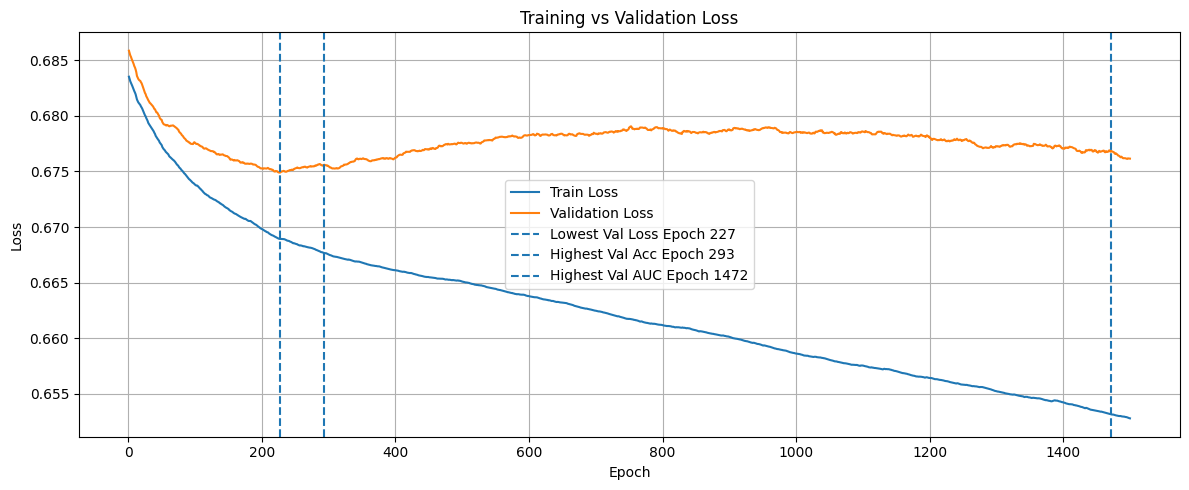

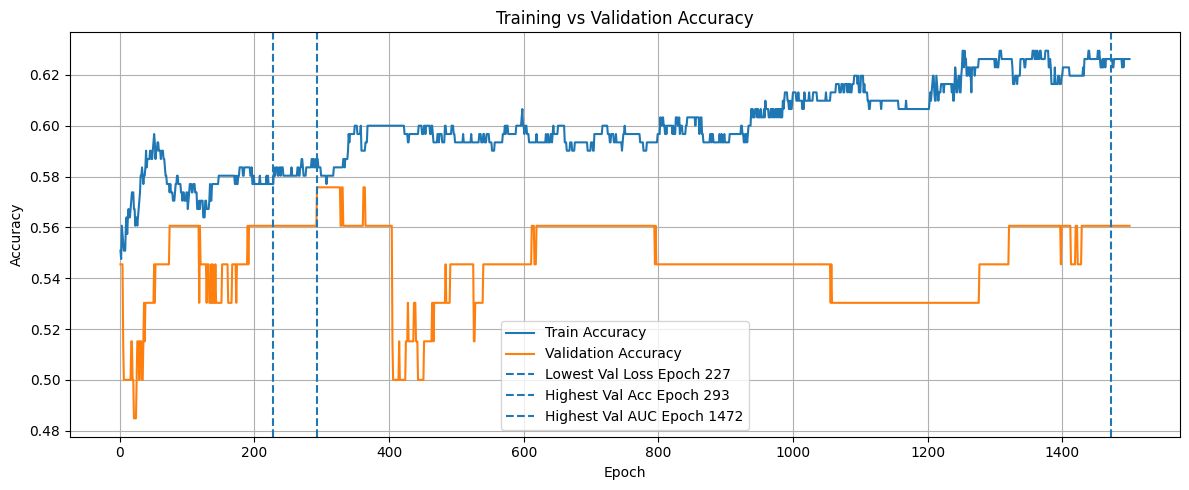

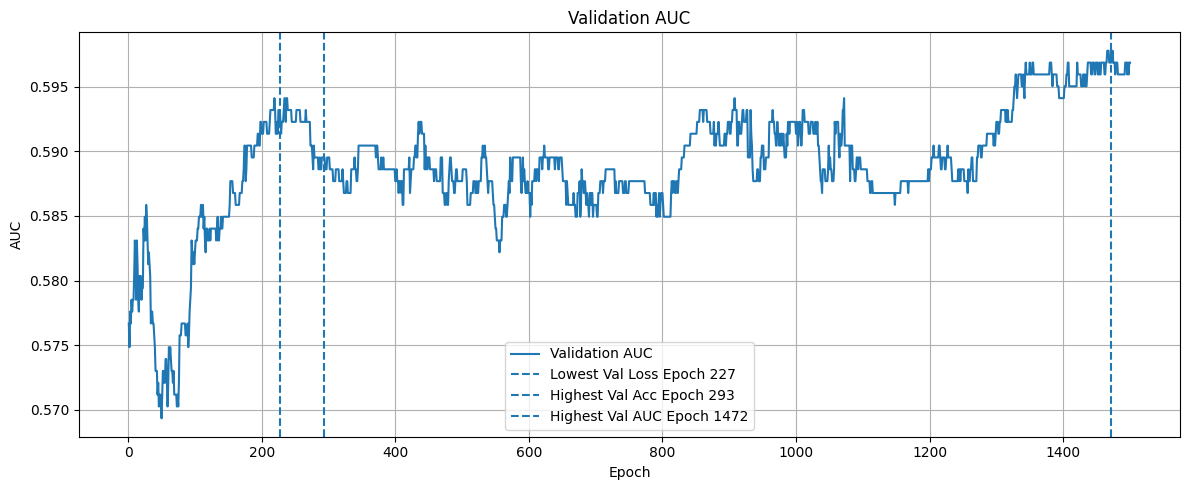


LOWEST VAL LOSS
Selected epoch: 227
Selected by: val_loss
Best validation value: 0.6748835444450378

---------- TEST DATASET RESULTS ----------
Test Loss:              0.6832
Test Accuracy:          0.5758
Test Balanced Accuracy: 0.5781
Test AUC:               0.5790
Test F1 Macro:          0.5742
Test F1 Weighted:       0.5734
Test F1 Class 0:        0.5484
Test F1 Class 1:        0.6000

Test Confusion Matrix:
[[17 17]
 [11 21]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.50      0.55        34
           1       0.55      0.66      0.60        32

    accuracy                           0.58        66
   macro avg       0.58      0.58      0.57        66
weighted avg       0.58      0.58      0.57        66



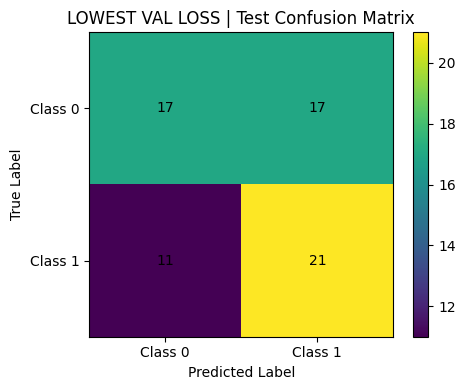

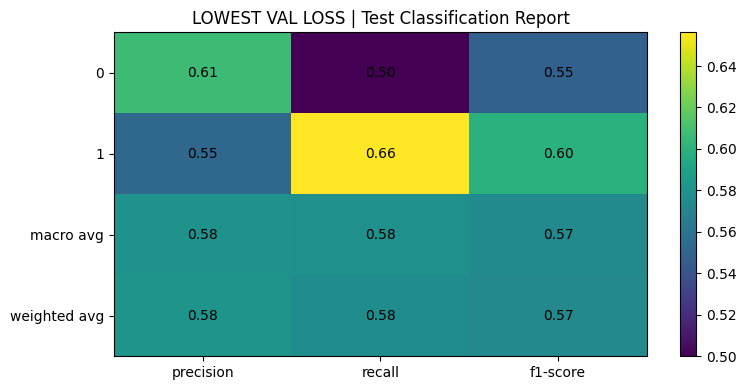


HIGHEST VAL ACCURACY
Selected epoch: 293
Selected by: val_accuracy
Best validation value: 0.5757575757575758

---------- TEST DATASET RESULTS ----------
Test Loss:              0.6809
Test Accuracy:          0.5758
Test Balanced Accuracy: 0.5781
Test AUC:               0.5873
Test F1 Macro:          0.5742
Test F1 Weighted:       0.5734
Test F1 Class 0:        0.5484
Test F1 Class 1:        0.6000

Test Confusion Matrix:
[[17 17]
 [11 21]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.50      0.55        34
           1       0.55      0.66      0.60        32

    accuracy                           0.58        66
   macro avg       0.58      0.58      0.57        66
weighted avg       0.58      0.58      0.57        66



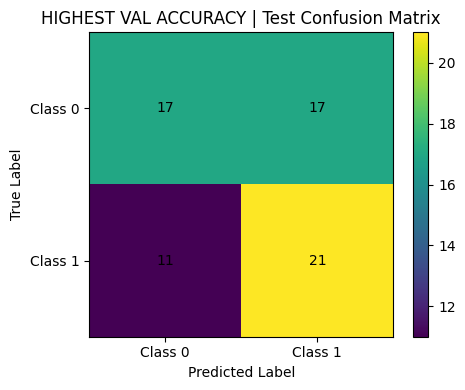

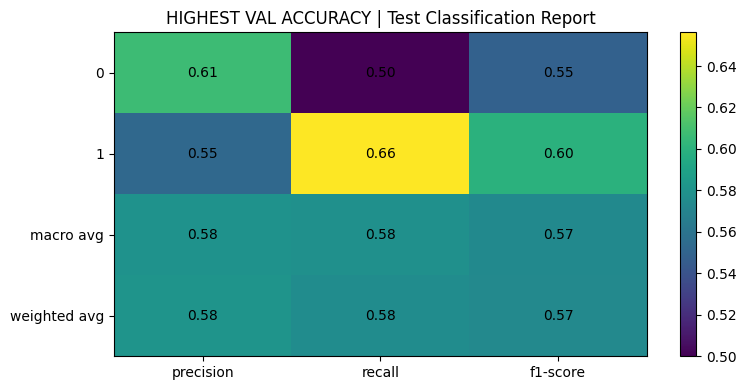


HIGHEST VAL AUC
Selected epoch: 1472
Selected by: val_auc
Best validation value: 0.5977961432506887

---------- TEST DATASET RESULTS ----------
Test Loss:              0.6671
Test Accuracy:          0.6667
Test Balanced Accuracy: 0.6673
Test AUC:               0.6517
Test F1 Macro:          0.6667
Test F1 Weighted:       0.6667
Test F1 Class 0:        0.6667
Test F1 Class 1:        0.6667

Test Confusion Matrix:
[[22 12]
 [10 22]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        34
           1       0.65      0.69      0.67        32

    accuracy                           0.67        66
   macro avg       0.67      0.67      0.67        66
weighted avg       0.67      0.67      0.67        66



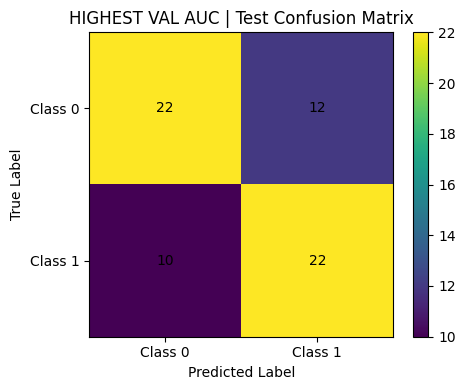

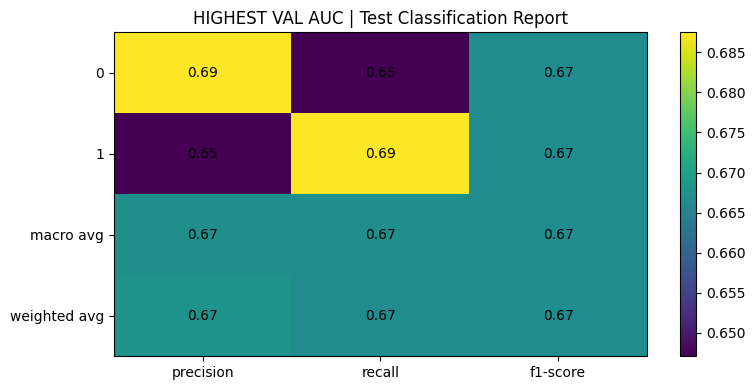


TEST DATASET CHECKPOINT COMPARISON
Checkpoint                | Epoch | Test Loss | Test Acc | Test BalAcc | Test AUC | F1 Macro |   F1 Wtd |    F1 C0 |    F1 C1
------------------------------------------------------------------------------------------------------------------------------------------------------
LOWEST VAL LOSS           |   227 |    0.6832 |   0.5758 |      0.5781 |   0.5790 |   0.5742 |   0.5734 |   0.5484 |   0.6000
HIGHEST VAL ACCURACY      |   293 |    0.6809 |   0.5758 |      0.5781 |   0.5873 |   0.5742 |   0.5734 |   0.5484 |   0.6000
HIGHEST VAL AUC           |  1472 |    0.6671 |   0.6667 |      0.6673 |   0.6517 |   0.6667 |   0.6667 |   0.6667 |   0.6667

BEST CHECKPOINTS ON TEST DATASET
Best Test Accuracy: HIGHEST VAL AUC | Epoch 1472 | Test Acc 0.6667
Best Test AUC:      HIGHEST VAL AUC | Epoch 1472 | Test AUC 0.6517
Best Test F1 Macro: HIGHEST VAL AUC | Epoch 1472 | F1 Macro 0.6667
Best Test Loss:     HIGHEST VAL AUC | Epoch 1472 | Test Loss 0.6671


In [ ]:
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score
)

# ==============================
# CONFIG
# ==============================

EPOCHS = 1500
PRINT_EVERY = 1

# ==============================
# HISTORY TRACKING
# ==============================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []
val_aucs = []

# ==============================
# BEST MODEL TRACKERS
# ==============================

best_auc = -np.inf
best_auc_epoch = 0
best_auc_state = None

best_acc = -np.inf
best_acc_epoch = 0
best_acc_state = None

best_loss = np.inf
best_loss_epoch = 0
best_loss_state = None

# ==============================
# MOVE FULL TENSORS TO DEVICE
# ==============================

X_train_t = X_train_t.to(device)
X_val_t = X_val_t.to(device)
X_test_t = X_test_t.to(device)

y_train_t = y_train_t.to(device)
y_val_t = y_val_t.to(device)
y_test_t = y_test_t.to(device)

# ==============================
# EVALUATION FUNCTION
# ==============================

def evaluate_model(model, X_t, y_t, criterion):
    model.eval()

    with torch.no_grad():
        logits = model(X_t)
        loss = criterion(logits, y_t).item()

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        y_true = y_t.detach().cpu().numpy()

        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

    acc = accuracy_score(y_true, preds)
    bal_acc = balanced_accuracy_score(y_true, preds)

    try:
        auc = roc_auc_score(y_true, probs)
    except ValueError:
        auc = np.nan

    return {
        "loss": loss,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "auc": auc,
        "preds": preds,
        "probs": probs,
        "y_true": y_true
    }

# ==============================
# TRAINING LOOP
# ==============================

for epoch in range(EPOCHS):
    model.train()

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

    train_metrics = evaluate_model(model, X_train_t, y_train_t, criterion)
    val_metrics = evaluate_model(model, X_val_t, y_val_t, criterion)

    train_loss = train_metrics["loss"]
    val_loss = val_metrics["loss"]

    train_acc = train_metrics["accuracy"]
    val_acc = val_metrics["accuracy"]
    val_auc = val_metrics["auc"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    val_aucs.append(val_auc)

    if not np.isnan(val_auc) and val_auc > best_auc:
        best_auc = val_auc
        best_auc_epoch = epoch + 1
        best_auc_state = copy.deepcopy(model.state_dict())

    if val_acc > best_acc:
        best_acc = val_acc
        best_acc_epoch = epoch + 1
        best_acc_state = copy.deepcopy(model.state_dict())

    if val_loss < best_loss:
        best_loss = val_loss
        best_loss_epoch = epoch + 1
        best_loss_state = copy.deepcopy(model.state_dict())

    if (epoch + 1) % PRINT_EVERY == 0:
        print(
            f"Epoch [{epoch + 1:03d}/{EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val AUC: {val_auc:.4f}"
        )

# ==============================
# PLOT TRAINING CURVES
# ==============================

epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.axvline(best_loss_epoch, linestyle="--", label=f"Lowest Val Loss Epoch {best_loss_epoch}")
plt.axvline(best_acc_epoch, linestyle="--", label=f"Highest Val Acc Epoch {best_acc_epoch}")
plt.axvline(best_auc_epoch, linestyle="--", label=f"Highest Val AUC Epoch {best_auc_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.axvline(best_loss_epoch, linestyle="--", label=f"Lowest Val Loss Epoch {best_loss_epoch}")
plt.axvline(best_acc_epoch, linestyle="--", label=f"Highest Val Acc Epoch {best_acc_epoch}")
plt.axvline(best_auc_epoch, linestyle="--", label=f"Highest Val AUC Epoch {best_auc_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(epochs, val_aucs, label="Validation AUC")
plt.axvline(best_loss_epoch, linestyle="--", label=f"Lowest Val Loss Epoch {best_loss_epoch}")
plt.axvline(best_acc_epoch, linestyle="--", label=f"Highest Val Acc Epoch {best_acc_epoch}")
plt.axvline(best_auc_epoch, linestyle="--", label=f"Highest Val AUC Epoch {best_auc_epoch}")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# FINAL TEST COMPARISON
# ==============================

best_models = {
    "LOWEST VAL LOSS": {
        "state": best_loss_state,
        "epoch": best_loss_epoch,
        "selection_metric": "val_loss",
        "selection_value": best_loss
    },
    "HIGHEST VAL ACCURACY": {
        "state": best_acc_state,
        "epoch": best_acc_epoch,
        "selection_metric": "val_accuracy",
        "selection_value": best_acc
    },
    "HIGHEST VAL AUC": {
        "state": best_auc_state,
        "epoch": best_auc_epoch,
        "selection_metric": "val_auc",
        "selection_value": best_auc
    }
}

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0, 1], ["Class 0", "Class 1"])
    plt.yticks([0, 1], ["Class 0", "Class 1"])
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


def plot_classification_report(report_dict, title):
    labels = ["0", "1", "macro avg", "weighted avg"]
    metrics = ["precision", "recall", "f1-score"]

    values = np.array([
        [report_dict[label][metric] for metric in metrics]
        for label in labels
    ])

    plt.figure(figsize=(8, 4))
    plt.imshow(values, aspect="auto")
    plt.title(title)
    plt.xticks(np.arange(len(metrics)), metrics)
    plt.yticks(np.arange(len(labels)), labels)
    plt.colorbar()

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            plt.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()


comparison_results = []

for checkpoint_name, info in best_models.items():
    print("\n" + "=" * 100)
    print(checkpoint_name)
    print("=" * 100)

    if info["state"] is None:
        print("No checkpoint saved.")
        continue

    model.load_state_dict(info["state"])

    test_result = evaluate_model(model, X_test_t, y_test_t, criterion)

    y_true = test_result["y_true"]
    y_pred = test_result["preds"]

    test_f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    test_f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    test_f1_class_0 = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    test_f1_class_1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    report_text = classification_report(
        y_true,
        y_pred,
        zero_division=0
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    print(f"Selected epoch: {info['epoch']}")
    print(f"Selected by: {info['selection_metric']}")
    print(f"Best validation value: {info['selection_value']}")

    print("\n---------- TEST DATASET RESULTS ----------")
    print(f"Test Loss:              {test_result['loss']:.4f}")
    print(f"Test Accuracy:          {test_result['accuracy']:.4f}")
    print(f"Test Balanced Accuracy: {test_result['balanced_accuracy']:.4f}")
    print(f"Test AUC:               {test_result['auc']:.4f}")
    print(f"Test F1 Macro:          {test_f1_macro:.4f}")
    print(f"Test F1 Weighted:       {test_f1_weighted:.4f}")
    print(f"Test F1 Class 0:        {test_f1_class_0:.4f}")
    print(f"Test F1 Class 1:        {test_f1_class_1:.4f}")

    print("\nTest Confusion Matrix:")
    print(cm)

    print("\nTest Classification Report:")
    print(report_text)

    plot_confusion_matrix(
        cm,
        title=f"{checkpoint_name} | Test Confusion Matrix"
    )

    plot_classification_report(
        report_dict,
        title=f"{checkpoint_name} | Test Classification Report"
    )

    comparison_results.append({
        "checkpoint": checkpoint_name,
        "selected_epoch": info["epoch"],
        "selected_by": info["selection_metric"],
        "selection_value": info["selection_value"],

        "test_loss": test_result["loss"],
        "test_accuracy": test_result["accuracy"],
        "test_balanced_accuracy": test_result["balanced_accuracy"],
        "test_auc": test_result["auc"],

        "test_f1_macro": test_f1_macro,
        "test_f1_weighted": test_f1_weighted,
        "test_f1_class_0": test_f1_class_0,
        "test_f1_class_1": test_f1_class_1,
    })

# ==============================
# CLEAN SUMMARY TABLE
# ==============================

print("\n" + "=" * 150)
print("TEST DATASET CHECKPOINT COMPARISON")
print("=" * 150)

print(
    f"{'Checkpoint':25s} | "
    f"{'Epoch':>5s} | "
    f"{'Test Loss':>9s} | "
    f"{'Test Acc':>8s} | "
    f"{'Test BalAcc':>11s} | "
    f"{'Test AUC':>8s} | "
    f"{'F1 Macro':>8s} | "
    f"{'F1 Wtd':>8s} | "
    f"{'F1 C0':>8s} | "
    f"{'F1 C1':>8s}"
)

print("-" * 150)

for r in comparison_results:
    print(
        f"{r['checkpoint']:25s} | "
        f"{r['selected_epoch']:5d} | "
        f"{r['test_loss']:9.4f} | "
        f"{r['test_accuracy']:8.4f} | "
        f"{r['test_balanced_accuracy']:11.4f} | "
        f"{r['test_auc']:8.4f} | "
        f"{r['test_f1_macro']:8.4f} | "
        f"{r['test_f1_weighted']:8.4f} | "
        f"{r['test_f1_class_0']:8.4f} | "
        f"{r['test_f1_class_1']:8.4f}"
    )

# ==============================
# BEST TEST CHECKPOINTS
# ==============================

if len(comparison_results) > 0:
    best_test_acc_result = max(
        comparison_results,
        key=lambda x: x["test_accuracy"]
    )

    best_test_auc_result = max(
        comparison_results,
        key=lambda x: x["test_auc"]
    )

    best_test_f1_result = max(
        comparison_results,
        key=lambda x: x["test_f1_macro"]
    )

    best_test_loss_result = min(
        comparison_results,
        key=lambda x: x["test_loss"]
    )

    print("\n" + "=" * 100)
    print("BEST CHECKPOINTS ON TEST DATASET")
    print("=" * 100)

    print(
        f"Best Test Accuracy: {best_test_acc_result['checkpoint']} "
        f"| Epoch {best_test_acc_result['selected_epoch']} "
        f"| Test Acc {best_test_acc_result['test_accuracy']:.4f}"
    )

    print(
        f"Best Test AUC:      {best_test_auc_result['checkpoint']} "
        f"| Epoch {best_test_auc_result['selected_epoch']} "
        f"| Test AUC {best_test_auc_result['test_auc']:.4f}"
    )

    print(
        f"Best Test F1 Macro: {best_test_f1_result['checkpoint']} "
        f"| Epoch {best_test_f1_result['selected_epoch']} "
        f"| F1 Macro {best_test_f1_result['test_f1_macro']:.4f}"
    )

    print(
        f"Best Test Loss:     {best_test_loss_result['checkpoint']} "
        f"| Epoch {best_test_loss_result['selected_epoch']} "
        f"| Test Loss {best_test_loss_result['test_loss']:.4f}"
    )